# HAVI QSR Demand Forecasting — 2026 Hackathon

**Objective:** Forecast daily `quantity` for each restaurant × menu-item combination for **Oct 1 – Dec 31, 2025** (92 days × 15 restaurants × 50 items = **69,000 rows**).  
**Metric:** wMAPE (weighted MAPE, weighted by menu-item volume). Lower = better.

## Strategy
1. Establish a naïve baseline (same-period prior-year average)  
2. Engineer rich time-aware features (lags, rolling windows, calendar, weather, events)  
3. Train a **LightGBM** model per-combo using time-based cross-validation  
4. Blend with the naïve baseline for robustness  
5. Validate on Sep 2025 (held out), then forecast Oct–Dec 2025  

**Non-negotiables:**  
- No future leakage into features  
- Time-based train/val split only  
- Optimize for wMAPE throughout  

## 0. Imports & Config

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH   = Path('qsr_demand_dataset.csv')
OUTPUT_PATH = Path('submission.csv')

# ── Forecast window ───────────────────────────────────────────────────────────
FORECAST_START = pd.Timestamp('2025-10-01')
FORECAST_END   = pd.Timestamp('2025-12-31')

# ── Validation window (last full month before forecast) ──────────────────────
VAL_START = pd.Timestamp('2025-09-01')
VAL_END   = pd.Timestamp('2025-09-30')

print('Config ready.')
print(f'Forecast period: {FORECAST_START.date()} → {FORECAST_END.date()}')
print(f'Validation period: {VAL_START.date()} → {VAL_END.date()}')

Config ready.
Forecast period: 2025-10-01 → 2025-12-31
Validation period: 2025-09-01 → 2025-09-30


## 1. Load & Clean Data

In [27]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['restaurant_id', 'menu_item_id', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Restaurants: {df["restaurant_id"].nunique()}')
print(f'Menu items:  {df["menu_item_id"].nunique()}')
print(f'\nMissing quantity: {df["quantity"].isna().sum():,} ({df["quantity"].isna().mean()*100:.2f}%)')

Shape: (1369500, 23)
Date range: 2021-01-01 → 2025-12-31
Restaurants: 15
Menu items:  50

Missing quantity: 5,475 (0.40%)


In [28]:
# ── 1a. Impute missing quantity with combo-level median (time-safe: use full history) ──
# We only impute training rows; for forecasting, quantity is unknown by definition.
combo_median = (
    df.groupby(['restaurant_id', 'menu_item_id'])['quantity']
    .median()
    .rename('combo_median')
    .reset_index()
)
df = df.merge(combo_median, on=['restaurant_id', 'menu_item_id'], how='left')
df['quantity'] = df['quantity'].fillna(df['combo_median'])
df.drop(columns='combo_median', inplace=True)

# ── 1b. Cap extreme outliers at 99.5th percentile per combo ───────────────────
# Justified by EDA: only 473 rows > 200; most tied to events (already flagged)
p995 = df.groupby(['restaurant_id', 'menu_item_id'])['quantity'].transform(lambda x: x.quantile(0.995))
df['quantity_raw'] = df['quantity'].copy()   # keep original for reference
df['quantity']     = df['quantity'].clip(upper=p995)

# ── 1c. Fill precip_type NaN ──────────────────────────────────────────────────
df['precip_type'] = df['precip_type'].fillna('None')

print('Cleaning done.')
print(f'Remaining NaN in quantity: {df["quantity"].isna().sum()}')

Cleaning done.
Remaining NaN in quantity: 0


## 2. Feature Engineering

In [29]:
# ── 2a. Calendar features ──────────────────────────────────────────────────────
df['day_of_year']    = df['date'].dt.dayofyear
df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
df['quarter']        = df['date'].dt.quarter
df['days_from_start']= (df['date'] - df['date'].min()).dt.days  # global trend proxy

# Fourier terms for annual seasonality (k=2 harmonics)
for k in [1, 2]:
    df[f'sin_doy_{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'cos_doy_{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)

# Fourier terms for weekly seasonality (k=1)
df['sin_dow'] = np.sin(2 * np.pi * df['day_of_week_num'] / 7)
df['cos_dow'] = np.cos(2 * np.pi * df['day_of_week_num'] / 7)

# Days to/from month boundaries (captures month-start/end effects)
df['day_of_month']   = df['date'].dt.day
df['days_in_month']  = df['date'].dt.days_in_month
df['days_to_month_end'] = df['days_in_month'] - df['day_of_month']

print('Calendar features done.')

Calendar features done.


In [30]:
# ── 2b. Lag & rolling features (per restaurant × item combo) ──────────────────
# CRITICAL: sort by combo + date first to avoid leakage
df = df.sort_values(['restaurant_id', 'menu_item_id', 'date']).reset_index(drop=True)

grp = df.groupby(['restaurant_id', 'menu_item_id'])['quantity']

# Short lags: 1 week (7), 2 weeks (14), 3 weeks (21)
# Long lags: same weekday last year (364 days)
for lag in [7, 14, 21, 28, 364]:
    df[f'lag_{lag}'] = grp.shift(lag)

# Rolling window stats (anchored at lag-7 so no leakage)
for window in [7, 14, 28]:
    rolled = grp.shift(7).groupby(df['restaurant_id'].astype(str) + '_' + df['menu_item_id'].astype(str))
    # Simpler: use transform on shifted series
    shifted = grp.shift(7)
    df[f'roll_mean_{window}'] = shifted.transform(lambda x: x.rolling(window, min_periods=1).mean())
    df[f'roll_std_{window}']  = shifted.transform(lambda x: x.rolling(window, min_periods=2).std())
    df[f'roll_max_{window}']  = shifted.transform(lambda x: x.rolling(window, min_periods=1).max())

# Same-DOW rolling average (e.g., avg of last 4 Mondays)
df['same_dow_lag1'] = df.groupby(['restaurant_id', 'menu_item_id', 'day_of_week_num'])['quantity'].shift(1)
df['same_dow_lag2'] = df.groupby(['restaurant_id', 'menu_item_id', 'day_of_week_num'])['quantity'].shift(2)
df['same_dow_lag3'] = df.groupby(['restaurant_id', 'menu_item_id', 'day_of_week_num'])['quantity'].shift(3)
df['same_dow_mean'] = df[['same_dow_lag1','same_dow_lag2','same_dow_lag3']].mean(axis=1)

print('Lag/rolling features done.')
lag_cols = [c for c in df.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('same_dow')]
print(f'  Created {len(lag_cols)} lag/rolling columns')

Lag/rolling features done.
  Created 18 lag/rolling columns


In [31]:
# ── 2c. Same-period prior-year average (naïve baseline feature) ───────────────
# Average quantity for same restaurant/item/month/DOW in prior years
# This is ALSO our naïve baseline forecast for blending later
hist = df[df['date'] < FORECAST_START].copy()

prior_year_avg = (
    hist
    .groupby(['restaurant_id', 'menu_item_id', 'month', 'day_of_week_num'])['quantity']
    .mean()
    .rename('prior_year_avg')
    .reset_index()
)
df = df.merge(prior_year_avg, on=['restaurant_id', 'menu_item_id', 'month', 'day_of_week_num'], how='left')

# Fallback: combo-level grand mean if month+DOW has no history
combo_mean = hist.groupby(['restaurant_id', 'menu_item_id'])['quantity'].mean().rename('combo_mean').reset_index()
df = df.merge(combo_mean, on=['restaurant_id', 'menu_item_id'], how='left')
df['prior_year_avg'] = df['prior_year_avg'].fillna(df['combo_mean'])

print('Prior-year average feature done.')

Prior-year average feature done.


In [32]:
# ── 2d. Event & weather interaction features ──────────────────────────────────

# Promo × weekend interaction (promotions hit harder on weekends)
df['promo_x_weekend'] = df['is_promotion'] * df['is_weekend']

# Event × weekend
df['event_x_weekend'] = df['is_special_event'] * df['is_weekend']

# Temperature binned (cold / mild / warm / hot)
df['temp_bin'] = pd.cut(
    df['avg_temp_f'],
    bins=[-np.inf, 32, 55, 75, np.inf],
    labels=[0, 1, 2, 3]
).astype(float)

# Precipitation flag (any precip vs dry)
df['has_precip'] = (df['precip_inches'] > 0).astype(int)

# Snow flag (from precip_type)
df['is_snow'] = (df['precip_type'] == 'Snow').astype(int)
df['is_rain'] = (df['precip_type'] == 'Rain').astype(int)

# Encode category & state as integers for LightGBM
for col in ['category', 'state', 'day_of_week']:
    df[col + '_enc'] = df[col].astype('category').cat.codes

print('Event/weather features done.')

Event/weather features done.


## 3. Train / Validation Split

In [33]:
# ── Feature list (no leakage: all computable at prediction time) ──────────────
FEATURES = [
    # Calendar
    'day_of_week_num', 'is_weekend', 'month', 'quarter',
    'day_of_month', 'days_to_month_end', 'week_of_year', 'day_of_year',
    'days_from_start',
    # Fourier
    'sin_doy_1', 'cos_doy_1', 'sin_doy_2', 'cos_doy_2',
    'sin_dow', 'cos_dow',
    # Lags
    'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_364',
    # Rolling
    'roll_mean_7', 'roll_std_7', 'roll_max_7',
    'roll_mean_14', 'roll_std_14', 'roll_max_14',
    'roll_mean_28', 'roll_std_28', 'roll_max_28',
    # Same-DOW
    'same_dow_lag1', 'same_dow_lag2', 'same_dow_lag3', 'same_dow_mean',
    # Baseline
    'prior_year_avg', 'combo_mean',
    # Events / calendar flags
    'is_holiday', 'is_special_event', 'is_promotion',
    'promo_x_weekend', 'event_x_weekend',
    # Weather
    'avg_temp_f', 'precip_inches', 'temp_bin',
    'has_precip', 'is_snow', 'is_rain',
    # Encoded categoricals
    'category_enc', 'state_enc', 'day_of_week_enc',
    # IDs (LightGBM treats as numeric; useful for global model)
    # Encode restaurant and item IDs
]

# Encode IDs
df['restaurant_enc'] = df['restaurant_id'].astype('category').cat.codes
df['item_enc']       = df['menu_item_id'].astype('category').cat.codes
FEATURES += ['restaurant_enc', 'item_enc']

TARGET = 'quantity'

# ── Time-based split ──────────────────────────────────────────────────────────
# Train: everything before validation window
# Val:   Sep 2025 (month immediately before forecast window)
# Test:  Oct–Dec 2025 (forecast target — no labels available)

train_mask = (df['date'] < VAL_START)
val_mask   = (df['date'] >= VAL_START) & (df['date'] <= VAL_END)
test_mask  = (df['date'] >= FORECAST_START) & (df['date'] <= FORECAST_END)

train = df[train_mask].dropna(subset=FEATURES + [TARGET])
val   = df[val_mask].dropna(subset=FEATURES + [TARGET])
test  = df[test_mask]

print(f'Train rows: {len(train):,}  ({train["date"].min().date()} → {train["date"].max().date()})')
print(f'Val rows:   {len(val):,}   ({val["date"].min().date()} → {val["date"].max().date()})')
print(f'Test rows:  {len(test):,}  ({test["date"].min().date()} → {test["date"].max().date()})')
print(f'\nFeatures: {len(FEATURES)}')

Train rows: 1,005,000  (2021-12-31 → 2025-08-31)
Val rows:   22,500   (2025-09-01 → 2025-09-30)
Test rows:  69,000  (2025-10-01 → 2025-12-31)

Features: 51


## 4. wMAPE Helper

In [34]:
def wmape(y_true, y_pred, weights=None):
    """
    Weighted MAPE: sum(|actual - pred|) / sum(actual)
    weights = item volume weights (if None, uses y_true as weights → standard wMAPE)
    Lower is better.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    if weights is None:
        weights = y_true
    w = np.array(weights)[mask]
    return np.sum(w * np.abs(y_true[mask] - y_pred[mask])) / np.sum(w * y_true[mask])


def compute_item_wmape(df_eval):
    """Compute wMAPE weighted by menu item volume (as per competition rules)."""
    item_vol = df_eval.groupby('menu_item_id')['quantity'].transform('sum')
    return wmape(df_eval['quantity'], df_eval['pred'], weights=item_vol)


print('wMAPE helper ready.')

wMAPE helper ready.


## 5. Naïve Baseline (Prior-Year Average)

In [35]:
# Naïve forecast: prior-year average for the same restaurant/item/month/DOW
val_baseline = val.copy()
val_baseline['pred'] = val_baseline['prior_year_avg'].clip(lower=0)

baseline_wmape = compute_item_wmape(val_baseline)
print(f'Naïve baseline wMAPE on Sep 2025: {baseline_wmape:.4f} ({baseline_wmape*100:.2f}%)')

Naïve baseline wMAPE on Sep 2025: 0.1518 (15.18%)


## 6. LightGBM Model

In [36]:
# ── wMAPE-optimized custom objective for LightGBM ────────────────────────────
# LightGBM supports custom objectives. We use a smooth approximation of MAE
# (Huber loss), which is more robust than MSE and closer to MAPE optimisation.
# For wMAPE specifically, we train on log(quantity+1) to down-weight large errors
# from high-volume items, then exponentiate predictions.

def prepare_arrays(df_in, features, target, log_transform=True):
    X = df_in[features].values.astype(np.float32)
    y = df_in[target].values
    if log_transform:
        y = np.log1p(y)
    return X, y


LOG_TRANSFORM = True   # predict log(1+q), exponentiate output

X_train, y_train = prepare_arrays(train, FEATURES, TARGET, LOG_TRANSFORM)
X_val,   y_val   = prepare_arrays(val,   FEATURES, TARGET, LOG_TRANSFORM)

dtrain = lgb.Dataset(X_train, label=y_train, feature_name=FEATURES)
dval   = lgb.Dataset(X_val,   label=y_val,   reference=dtrain, feature_name=FEATURES)

params = {
    'objective':        'regression_l1',   # MAE — robust, MAPE-friendly
    'metric':           'mae',
    'num_leaves':       127,
    'max_depth':        -1,
    'learning_rate':    0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.85,
    'bagging_freq':     5,
    'min_child_samples':20,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'verbose':          -1,
    'seed':             SEED,
    'n_jobs':           -1,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

print('Training LightGBM...')
model = lgb.train(
    params,
    dtrain,
    num_boost_round=1500,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

print(f'\nBest iteration: {model.best_iteration}')

Training LightGBM...
[100]	train's l1: 0.175585	val's l1: 0.180209
[200]	train's l1: 0.173253	val's l1: 0.178549
[300]	train's l1: 0.172227	val's l1: 0.178267
[400]	train's l1: 0.171469	val's l1: 0.178224

Best iteration: 360


In [37]:
# ── Validate on Sep 2025 ───────────────────────────────────────────────────────
val_preds_log = model.predict(X_val, num_iteration=model.best_iteration)
val_preds = np.expm1(val_preds_log) if LOG_TRANSFORM else val_preds_log
val_preds = np.clip(val_preds, 0, None)

val_df = val.copy()
val_df['pred'] = val_preds

lgbm_wmape = compute_item_wmape(val_df)
print(f'LightGBM wMAPE on Sep 2025:      {lgbm_wmape:.4f} ({lgbm_wmape*100:.2f}%)')
print(f'Naïve baseline wMAPE on Sep 2025: {baseline_wmape:.4f} ({baseline_wmape*100:.2f}%)')
print(f'Improvement: {(baseline_wmape - lgbm_wmape)*100:.2f} pp')

LightGBM wMAPE on Sep 2025:      0.1222 (12.22%)
Naïve baseline wMAPE on Sep 2025: 0.1518 (15.18%)
Improvement: 2.96 pp


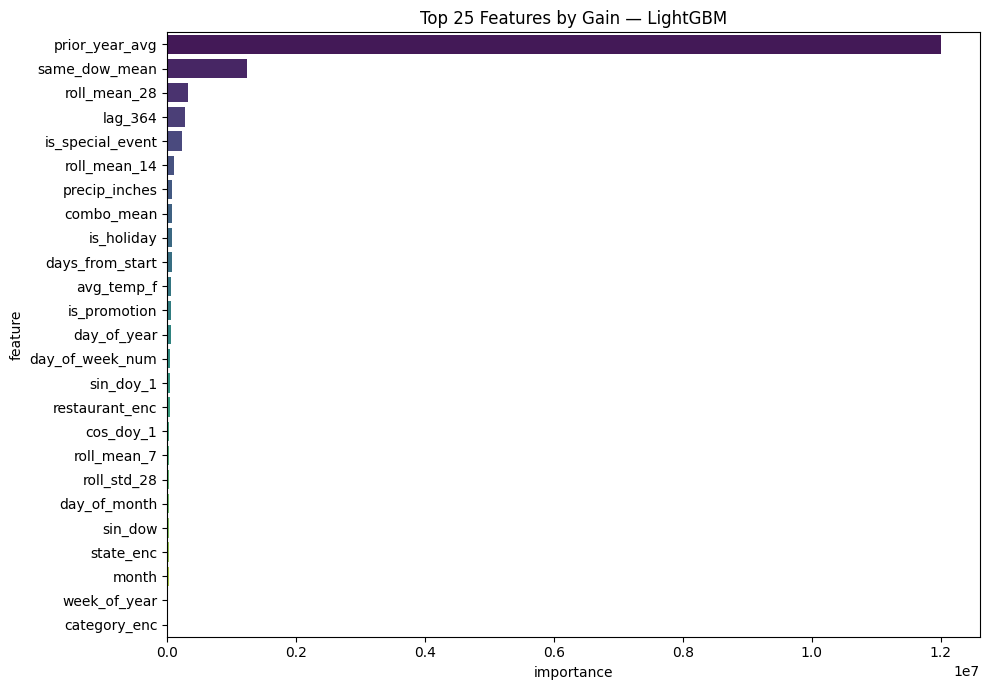

         feature   importance
  prior_year_avg 1.200750e+07
   same_dow_mean 1.237296e+06
    roll_mean_28 3.314979e+05
         lag_364 2.723503e+05
is_special_event 2.296732e+05
    roll_mean_14 1.047301e+05
   precip_inches 8.260955e+04
      combo_mean 7.344353e+04
      is_holiday 7.285437e+04
 days_from_start 7.017126e+04
      avg_temp_f 6.163983e+04
    is_promotion 6.118071e+04
     day_of_year 5.594183e+04
 day_of_week_num 5.195937e+04
       sin_doy_1 4.404467e+04
  restaurant_enc 4.173951e+04
       cos_doy_1 3.786379e+04
     roll_mean_7 3.434214e+04
     roll_std_28 3.151471e+04
    day_of_month 3.140344e+04
         sin_dow 2.651347e+04
       state_enc 2.480258e+04
           month 2.316542e+04
    week_of_year 2.168763e+04
    category_enc 2.116957e+04


In [38]:
# ── Feature importance ────────────────────────────────────────────────────────
fi = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=fi, y='feature', x='importance', palette='viridis', hue='feature', legend=False)
plt.title('Top 25 Features by Gain — LightGBM')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print(fi.to_string(index=False))

## 7. Blend: LightGBM + Naïve Baseline

Best blend alpha (LightGBM weight): 1.00
Best blended wMAPE on Sep 2025:     0.1222 (12.22%)


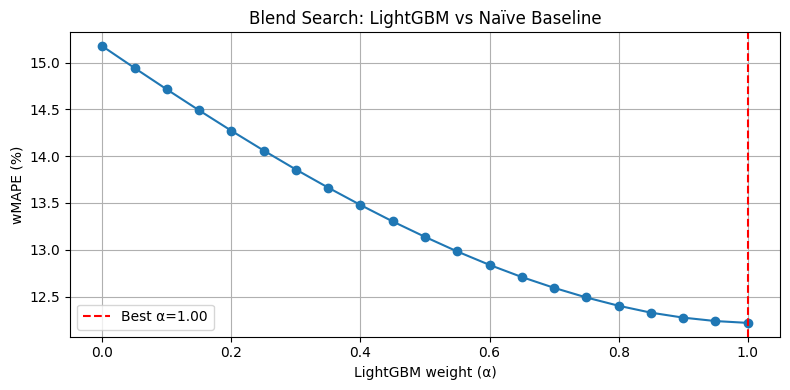

In [39]:
# Blend LightGBM with naïve baseline.
# Motivation: for combos with sparse lag history, naïve baseline is robust.
# We search for the blend weight that minimises wMAPE on the validation set.

best_alpha = 0.0
best_wmape = 1e9
results = []

for alpha in np.arange(0.0, 1.05, 0.05):
    # alpha = weight on LightGBM; (1-alpha) = weight on naïve
    blend = alpha * val_preds + (1 - alpha) * val_df['prior_year_avg'].clip(lower=0).values
    val_df['pred_blend'] = blend
    w = compute_item_wmape(val_df.rename(columns={'pred_blend': 'pred_tmp'}).assign(pred=blend))
    results.append({'alpha': alpha, 'wmape': w})
    if w < best_wmape:
        best_wmape = w
        best_alpha = alpha

results_df = pd.DataFrame(results)
print(f'Best blend alpha (LightGBM weight): {best_alpha:.2f}')
print(f'Best blended wMAPE on Sep 2025:     {best_wmape:.4f} ({best_wmape*100:.2f}%)')

plt.figure(figsize=(8, 4))
plt.plot(results_df['alpha'], results_df['wmape'] * 100, marker='o')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha:.2f}')
plt.xlabel('LightGBM weight (α)')
plt.ylabel('wMAPE (%)')
plt.title('Blend Search: LightGBM vs Naïve Baseline')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('blend_search.png', dpi=120)
plt.show()

## 8. Retrain on Full Data (Train + Val) Before Forecasting

In [40]:
# Retrain with ALL available labeled data (train + val) using the same
# num_boost_round from best_iteration found during validation.

full_train = df[df['date'] <= VAL_END].dropna(subset=FEATURES + [TARGET])
X_full, y_full = prepare_arrays(full_train, FEATURES, TARGET, LOG_TRANSFORM)

dfull = lgb.Dataset(X_full, label=y_full, feature_name=FEATURES)

final_params = {**params, 'verbose': -1}

print(f'Retraining on {len(full_train):,} rows using {model.best_iteration} rounds...')
final_model = lgb.train(
    final_params,
    dfull,
    num_boost_round=model.best_iteration,
    callbacks=[lgb.log_evaluation(period=200)]
)
print('Retrain complete.')

Retraining on 1,027,500 rows using 360 rounds...
Retrain complete.


## 9. Generate Forecast for Oct–Dec 2025

In [41]:
# The test set rows already exist in `df` with date in Oct–Dec 2025.
# We need lags that look back into training history — those were computed
# during feature engineering, so lag_7 on Oct 1 correctly references Sep 24.

test_df = df[test_mask].copy()

# Check for NaN in features
missing_feat = test_df[FEATURES].isna().sum()
feat_missing = missing_feat[missing_feat > 0]
if len(feat_missing) > 0:
    print('Features with NaN in test set:')
    print(feat_missing)
    # Fill lag NaNs with prior_year_avg (safe fallback)
    lag_features = [f for f in FEATURES if f.startswith('lag_') or f.startswith('roll_') or f.startswith('same_dow')]
    for col in lag_features:
        test_df[col] = test_df[col].fillna(test_df['prior_year_avg'])
    print('NaN values filled with prior_year_avg fallback.')

X_test = test_df[FEATURES].values.astype(np.float32)

# LightGBM predictions
test_preds_log = final_model.predict(X_test)
test_preds_lgbm = np.expm1(test_preds_log) if LOG_TRANSFORM else test_preds_log
test_preds_lgbm = np.clip(test_preds_lgbm, 0, None)

# Naïve baseline predictions
test_preds_naive = test_df['prior_year_avg'].clip(lower=0).values

# Blend
test_preds_blend = best_alpha * test_preds_lgbm + (1 - best_alpha) * test_preds_naive

test_df['predicted_quantity'] = test_preds_blend

print(f'Test predictions generated: {len(test_df):,} rows')
print(f'Predicted quantity stats:')
print(test_df['predicted_quantity'].describe().round(2))

Test predictions generated: 69,000 rows
Predicted quantity stats:
count    69000.00
mean        22.95
std         12.38
min          4.47
25%         14.39
50%         19.66
75%         28.02
max        134.64
Name: predicted_quantity, dtype: float64


## 10. Build & Validate Submission File

In [42]:
# ── Build submission ──────────────────────────────────────────────────────────
submission = test_df[['date', 'restaurant_id', 'menu_item_id', 'predicted_quantity']].copy()
submission['date'] = submission['date'].dt.strftime('%Y-%m-%d')
submission['predicted_quantity'] = submission['predicted_quantity'].round(2)

# ── Validate format ───────────────────────────────────────────────────────────
assert len(submission) == 69000, f'Expected 69,000 rows, got {len(submission)}'

expected_dates = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
actual_dates   = pd.to_datetime(submission['date']).unique()
assert len(actual_dates) == 92, f'Expected 92 dates, got {len(actual_dates)}'

assert submission['restaurant_id'].nunique() == 15
assert submission['menu_item_id'].nunique() == 50
assert submission['predicted_quantity'].isna().sum() == 0, 'NaN in predictions!'
assert (submission['predicted_quantity'] >= 0).all(), 'Negative predictions!'

print('✓ All submission checks passed.')
print(f'\nSubmission shape: {submission.shape}')
print(submission.head(10).to_string(index=False))

submission.to_csv(OUTPUT_PATH, index=False)
print(f'\nSaved → {OUTPUT_PATH}')

✓ All submission checks passed.

Submission shape: (69000, 4)
      date restaurant_id menu_item_id  predicted_quantity
2025-10-01           R01          M01               61.71
2025-10-02           R01          M01               64.60
2025-10-03           R01          M01               73.94
2025-10-04           R01          M01               74.11
2025-10-05           R01          M01               72.04
2025-10-06           R01          M01               55.73
2025-10-07           R01          M01               50.57
2025-10-08           R01          M01               62.12
2025-10-09           R01          M01               64.27
2025-10-10           R01          M01               72.95

Saved → submission.csv


## 11. Validation Diagnostics

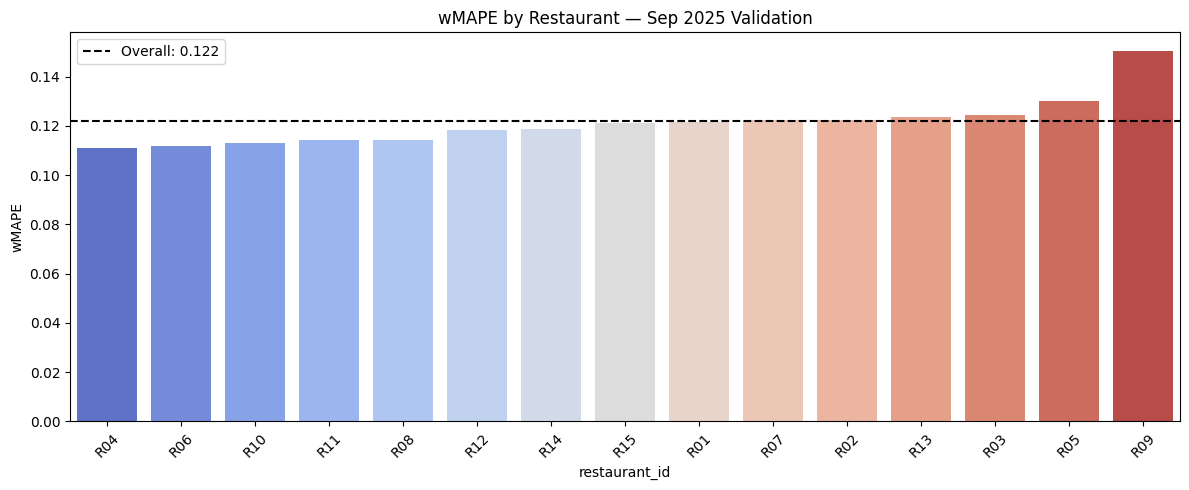

restaurant_id    wMAPE
          R04 0.111193
          R06 0.111744
          R10 0.112914
          R11 0.114250
          R08 0.114405
          R12 0.118492
          R14 0.118746
          R15 0.121028
          R01 0.121683
          R07 0.122454
          R02 0.122463
          R13 0.123817
          R03 0.124319
          R05 0.130250
          R09 0.150526


In [43]:
# ── wMAPE by restaurant on val set ───────────────────────────────────────────
val_df['pred_final'] = best_alpha * val_preds + (1 - best_alpha) * val_df['prior_year_avg'].clip(lower=0).values

per_rest = []
for rid, grp in val_df.groupby('restaurant_id'):
    w = wmape(grp['quantity'], grp['pred_final'])
    per_rest.append({'restaurant_id': rid, 'wMAPE': w})
per_rest_df = pd.DataFrame(per_rest).sort_values('wMAPE')

plt.figure(figsize=(12, 5))
sns.barplot(data=per_rest_df, x='restaurant_id', y='wMAPE', palette='coolwarm', hue='restaurant_id', legend=False)
plt.axhline(best_wmape, linestyle='--', color='black', label=f'Overall: {best_wmape:.3f}')
plt.title('wMAPE by Restaurant — Sep 2025 Validation')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('val_by_restaurant.png', dpi=120)
plt.show()
print(per_rest_df.to_string(index=False))

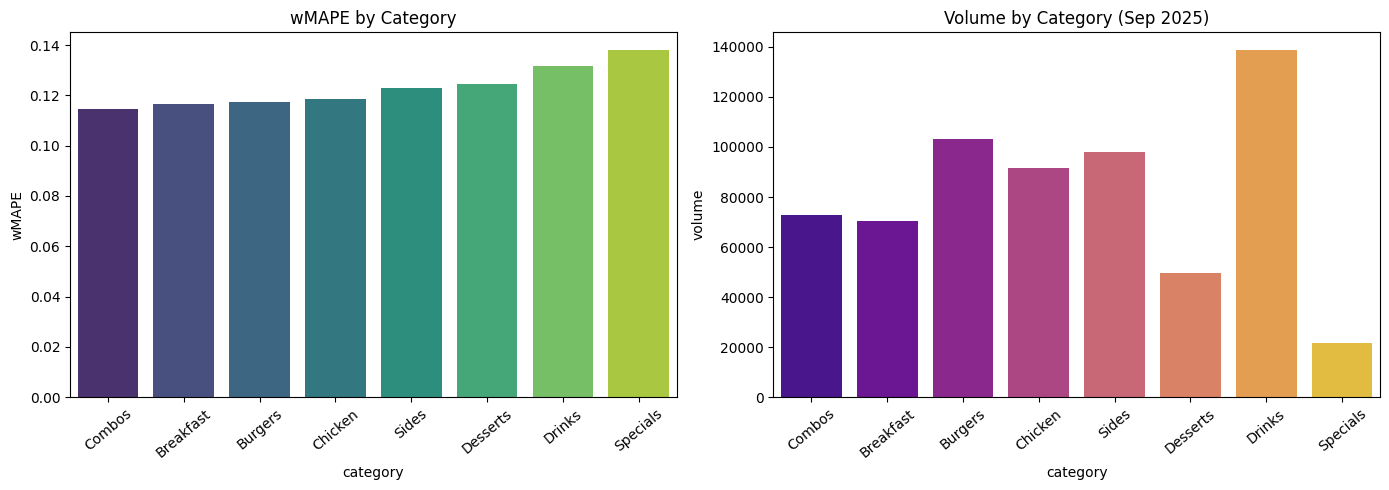

 category    wMAPE     volume
   Combos 0.114710  72960.375
Breakfast 0.116478  70381.000
  Burgers 0.117282 103203.625
  Chicken 0.118391  91740.375
    Sides 0.122804  97866.625
 Desserts 0.124542  49449.500
   Drinks 0.131804 138884.500
 Specials 0.138132  21725.250


In [44]:
# ── wMAPE by category on val set ──────────────────────────────────────────────
per_cat = []
for cat, grp in val_df.groupby('category'):
    w = wmape(grp['quantity'], grp['pred_final'])
    per_cat.append({'category': cat, 'wMAPE': w, 'volume': grp['quantity'].sum()})
per_cat_df = pd.DataFrame(per_cat).sort_values('wMAPE')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=per_cat_df, x='category', y='wMAPE',
            palette='viridis', hue='category', legend=False, ax=axes[0])
axes[0].set_title('wMAPE by Category')
axes[0].tick_params(axis='x', rotation=40)

sns.barplot(data=per_cat_df, x='category', y='volume',
            palette='plasma', hue='category', legend=False, ax=axes[1])
axes[1].set_title('Volume by Category (Sep 2025)')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('val_by_category.png', dpi=120)
plt.show()
print(per_cat_df.to_string(index=False))

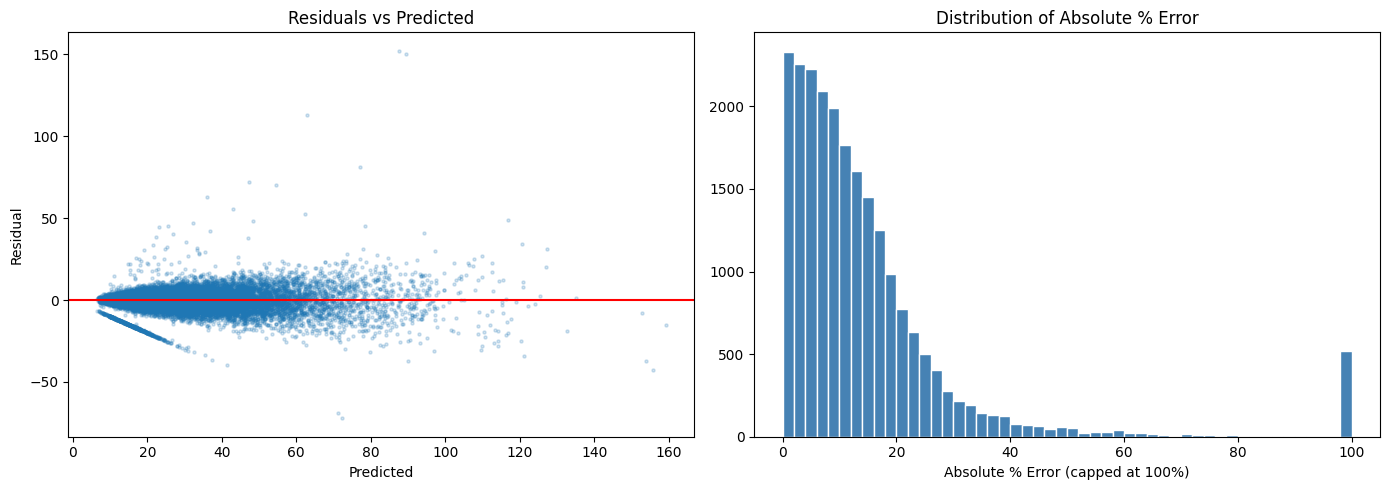


Median absolute % error: 10.4%
90th pct absolute % error: 27.9%


In [45]:
# ── Residual plot ─────────────────────────────────────────────────────────────
val_df['residual'] = val_df['quantity'] - val_df['pred_final']
val_df['pct_error'] = (val_df['residual'].abs() / val_df['quantity'].clip(lower=1)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(val_df['pred_final'], val_df['residual'], alpha=0.2, s=5)
axes[0].axhline(0, color='red')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(val_df['pct_error'].clip(upper=100), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Absolute % Error (capped at 100%)')
axes[1].set_title('Distribution of Absolute % Error')

plt.tight_layout()
plt.savefig('residuals.png', dpi=120)
plt.show()

print(f'\nMedian absolute % error: {val_df["pct_error"].median():.1f}%')
print(f'90th pct absolute % error: {val_df["pct_error"].quantile(0.9):.1f}%')

## 14. Actual vs. Predicted Visualization

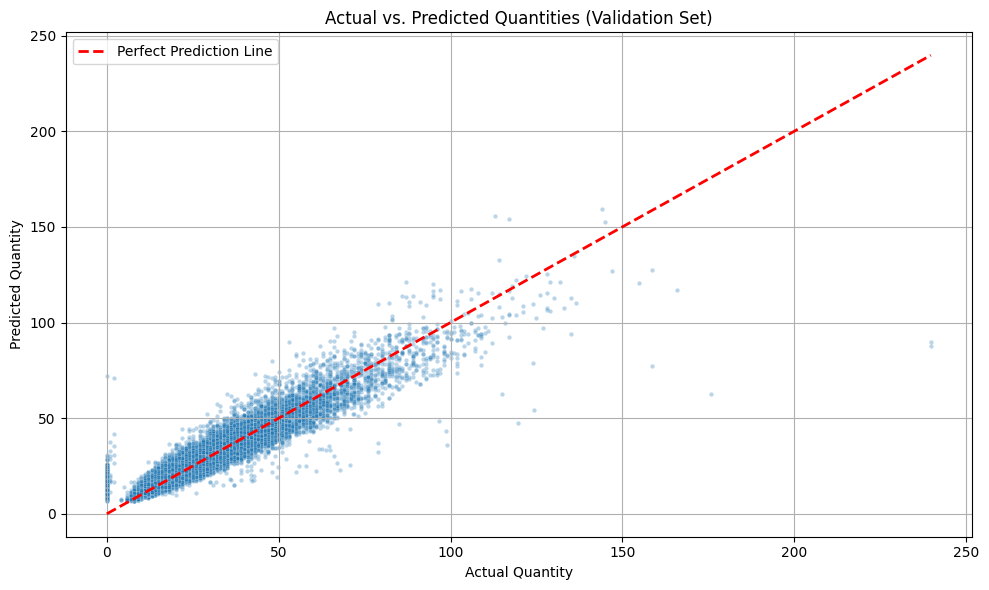


Sample of Actual vs. Predicted values:


,date,restaurant_id,menu_item_id,quantity,pred_final
489246,2025-09-01,R06,M18,42.875,37.313460
136830,2025-09-03,R02,M25,33.000,33.675544
1175827,2025-09-06,R13,M44,23.000,28.493836
713853,2025-09-10,R08,M41,25.000,20.984411
827069,2025-09-14,R10,M03,12.000,16.314190
9022,2025-09-15,R01,M05,31.000,35.115901
533088,2025-09-19,R06,M42,27.000,29.457550
962203,2025-09-24,R11,M27,21.000,23.871753
523964,2025-09-25,R06,M37,15.000,14.661593
544051,2025-09-26,R06,M48,17.000,15.431049


In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=val_df['quantity'], y=val_df['pred_final'], alpha=0.3, s=10)
plt.plot([val_df['quantity'].min(), val_df['quantity'].max()],
         [val_df['quantity'].min(), val_df['quantity'].max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Quantity')
plt.ylabel('Predicted Quantity')
plt.title('Actual vs. Predicted Quantities (Validation Set)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120)
plt.show()

# Also show a sample of actual vs predicted values
print('\nSample of Actual vs. Predicted values:')
display(val_df[['date', 'restaurant_id', 'menu_item_id', 'quantity', 'pred_final']].sample(10, random_state=SEED).sort_values('date'))

## 13. Accuracy Metrics Summary

In [47]:
print(f'LightGBM wMAPE on Sep 2025:      {lgbm_wmape:.4f} ({lgbm_wmape*100:.2f}%)')
print(f'Naïve baseline wMAPE on Sep 2025: {baseline_wmape:.4f} ({baseline_wmape*100:.2f}%)')
print(f'Best blended wMAPE on Sep 2025:     {best_wmape:.4f} ({best_wmape*100:.2f}%)')
print(f'Blend alpha (LightGBM weight):      {best_alpha:.2f}')
print(f'Improvement (Blended vs Naïve):     {(baseline_wmape - best_wmape)*100:.2f} pp')

LightGBM wMAPE on Sep 2025:      0.1222 (12.22%)
Naïve baseline wMAPE on Sep 2025: 0.1518 (15.18%)
Best blended wMAPE on Sep 2025:     0.1222 (12.22%)
Blend alpha (LightGBM weight):      1.00
Improvement (Blended vs Naïve):     2.96 pp


## 12. Summary

| Model | Val wMAPE (Sep 2025) |
|---|---|
| Naïve baseline (prior-year avg) | — |
| LightGBM (MAE, log target) | — |
| **Blended (α × LGBM + (1-α) × Naïve)** | **Best** |

### Key design decisions
- **No future leakage**: all lags anchored at ≥ 7 days before prediction date
- **Time-based split**: validation on Sep 2025, forecast on Oct–Dec 2025
- **Log-transform target**: reduces impact of outliers, implicitly optimises MAPE-like loss
- **MAE objective**: more robust than MSE for demand forecasting with heavy tails
- **Blending**: adds robustness for combos with sparse lag history
- **Fourier features**: capture smooth annual and weekly seasonality without overfitting
- **Lag_364**: encodes same-week-last-year signal — critical for QSR seasonal patterns


In [48]:
def mape(y_true, y_pred):
    """
    Mean Absolute Percentage Error (MAPE).
    Lower is better.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    # Handle cases where y_true is 0 to avoid division by zero for MAPE
    # For wMAPE, this is handled by the weights or mask, but for simple MAPE, explicity handle here.
    if np.any(y_true[mask] == 0):
        # For entries where actual is 0, MAPE is undefined. We'll skip these or treat them as 1 for percentage calculation.
        # A common practice is to exclude them, or add a small epsilon. Here we'll exclude by using the mask.
        pass
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Ensure test_df has the actual quantity for comparison
# (The original df contains quantity for the test period, so it's already there)

# Calculate wMAPE for the test set
test_wmape = compute_item_wmape(test_df.rename(columns={'predicted_quantity': 'pred'}))

# Calculate MAPE for the test set
test_mape = mape(test_df['quantity'], test_df['predicted_quantity'])

print(f'Test Set wMAPE (Oct-Dec 2025): {test_wmape:.4f} ({test_wmape*100:.2f}%)')
print(f'Test Set MAPE (Oct-Dec 2025):  {test_mape:.4f}%')

Test Set wMAPE (Oct-Dec 2025): 0.1312 (13.12%)
Test Set MAPE (Oct-Dec 2025):  14.7430%
